# E-commerce A/B Testing with Revenue Forecasting

## Notebook 6: A/B Testing and Scenario Analysis

This notebook connects experiment uplift to revenue forecasting scenarios. The goal is to translate observed A/B performance differences into practical business cases for future revenue planning.

## Goals

1. Review experiment uplift metrics
2. Select the uplift measure for scenario translation
3. Load the best forecast benchmark
4. Build conservative, base, and optimistic revenue scenarios
5. Estimate incremental revenue impact

In [1]:
# Import libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set display options and project paths

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent
PREPROCESSED_DIR = PROJECT_ROOT / "data" / "02-preprocessed"
FEATURES_DIR = PROJECT_ROOT / "data" / "03-features"
PREDICTIONS_DIR = PROJECT_ROOT / "data" / "04-predictions"

print("Project root:", PROJECT_ROOT)
print("Preprocessed dir exists:", PREPROCESSED_DIR.exists())
print("Features dir exists:", FEATURES_DIR.exists())
print("Predictions dir exists:", PREDICTIONS_DIR.exists())

Project root: c:\Users\tevin\OneDrive\Desktop\General-Machine-Learning\revenue_forecasting
Preprocessed dir exists: True
Features dir exists: True
Predictions dir exists: True


In [3]:
# Load experiment and forecast outputs

ab_df = pd.read_csv(PREPROCESSED_DIR / "ab_test_clean.csv", parse_dates=["date"])
ab_variant_features = pd.read_csv(FEATURES_DIR / "ab_variant_features.csv")
ab_uplift_summary = pd.read_csv(FEATURES_DIR / "ab_uplift_summary.csv")
scenario_multipliers = pd.read_csv(FEATURES_DIR / "scenario_multipliers.csv")

baseline_results_df = pd.read_csv(PREDICTIONS_DIR / "baseline_time_series_results.csv")
prophet_tuning_results_df = pd.read_csv(PREDICTIONS_DIR / "prophet_tuning_results.csv")
combined_model_results_df = pd.read_csv(PREDICTIONS_DIR / "combined_model_results.csv")

print("ab_df shape:", ab_df.shape)
print("ab_variant_features shape:", ab_variant_features.shape)
print("ab_uplift_summary shape:", ab_uplift_summary.shape)
print("scenario_multipliers shape:", scenario_multipliers.shape)

ab_df shape: (60, 11)
ab_variant_features shape: (2, 13)
ab_uplift_summary shape: (4, 5)
scenario_multipliers shape: (3, 3)


## Review Experiment Uplift

This section reviews the variant-level feature table and uplift summary before selecting a business-facing uplift metric.

In [4]:
# Preview experiment feature tables

ab_variant_features

,variant,total_spend,total_impressions,total_reach,total_clicks,total_searches,total_view_content,total_add_to_cart,total_purchases,ctr,purchase_rate_from_click,purchase_rate_from_impression,cost_per_purchase
0,control,68653,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,0.048565,0.098255,0.004772,4.528263
1,test,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,0.080879,0.086407,0.006988,4.917312


In [5]:
# Review uplift summary

ab_uplift_summary

,metric,control_value,test_value,absolute_diff,relative_uplift_pct
0,ctr,0.048565,0.080879,0.032314,66.536601
1,purchase_rate_from_click,0.098255,0.086407,-0.011848,-12.058601
2,purchase_rate_from_impression,0.004772,0.006988,0.002217,46.454617
3,cost_per_purchase,4.528263,4.917312,0.389048,8.591554


## A/B Test Statistical Analysis

This section tests whether the observed differences between control and test look statistically meaningful before translating uplift into revenue scenarios.

In [18]:
# Import statistical testing library

from scipy.stats import ttest_ind

In [19]:
# Build daily A/B metric table

ab_daily = (
    ab_df.groupby(["date", "variant"], as_index=False)
    .agg(
        spend_usd=("spend_usd", "sum"),
        impressions=("impressions", "sum"),
        website_clicks=("website_clicks", "sum"),
        view_content=("view_content", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        purchase=("purchase", "sum")
    )
    .sort_values(["date", "variant"])
)

ab_daily["ctr"] = ab_daily["website_clicks"] / ab_daily["impressions"].replace(0, np.nan)
ab_daily["purchase_rate_from_click"] = ab_daily["purchase"] / ab_daily["website_clicks"].replace(0, np.nan)
ab_daily["purchase_rate_from_impression"] = ab_daily["purchase"] / ab_daily["impressions"].replace(0, np.nan)
ab_daily["add_to_cart_rate"] = ab_daily["add_to_cart"] / ab_daily["view_content"].replace(0, np.nan)

ab_daily.head()

,date,variant,spend_usd,impressions,website_clicks,view_content,add_to_cart,purchase,ctr,purchase_rate_from_click,purchase_rate_from_impression,add_to_cart_rate
0,2019-01-08,control,2280,82702.0,7016.0,2159.0,1819.0,618.0,0.084835,0.088084,0.007473,0.842520
1,2019-01-08,test,3008,39550.0,3038.0,1069.0,894.0,255.0,0.076814,0.083937,0.006448,0.836296
2,2019-02-08,control,1757,121040.0,8110.0,1841.0,1219.0,511.0,0.067003,0.063009,0.004222,0.662140
3,2019-02-08,test,2542,100719.0,4657.0,1548.0,879.0,677.0,0.046238,0.145373,0.006722,0.567829
4,2019-03-08,control,2343,131711.0,6508.0,1549.0,1134.0,372.0,0.049411,0.057160,0.002824,0.732085


In [20]:
# Split control and test daily metrics

control_daily = ab_daily[ab_daily["variant"] == "control"].copy()
test_daily = ab_daily[ab_daily["variant"] == "test"].copy()

print("Control rows:", len(control_daily))
print("Test rows:", len(test_daily))

Control rows: 12
Test rows: 12


## Hypotheses

Primary metric: purchase rate from click

Null hypothesis:
The average daily purchase rate from click is the same for control and test.

Alternative hypothesis:
The average daily purchase rate from click is different for control and test.

In [21]:
# Run Welch t-tests on daily metrics

metrics_to_test = [
    "ctr",
    "purchase_rate_from_click",
    "purchase_rate_from_impression",
    "purchase",
    "add_to_cart_rate"
]

ab_test_results = []

for metric in metrics_to_test:
    control_values = control_daily[metric].dropna()
    test_values = test_daily[metric].dropna()
    
    t_stat, p_value = ttest_ind(
        test_values,
        control_values,
        equal_var=False,
        nan_policy="omit"
    )
    
    control_mean = control_values.mean()
    test_mean = test_values.mean()
    absolute_diff = test_mean - control_mean
    relative_uplift_pct = (absolute_diff / control_mean) * 100 if control_mean != 0 else np.nan
    
    ab_test_results.append({
        "metric": metric,
        "control_mean": control_mean,
        "test_mean": test_mean,
        "absolute_diff": absolute_diff,
        "relative_uplift_pct": relative_uplift_pct,
        "t_stat": t_stat,
        "p_value": p_value
    })

ab_test_results_df = pd.DataFrame(ab_test_results).sort_values("p_value")
ab_test_results_df

,metric,control_mean,test_mean,absolute_diff,relative_uplift_pct,t_stat,p_value
0,ctr,0.049577,0.098785,0.049207,99.254164,2.671075,0.017675
2,purchase_rate_from_impression,0.005098,0.009026,0.003928,77.040690,2.671445,0.018781
4,add_to_cart_rate,0.781160,0.600462,-0.180698,-23.132014,-1.560543,0.135320
1,purchase_rate_from_click,0.135305,0.104196,-0.031109,-22.991798,-0.979956,0.342188
3,purchase,505.833333,577.000000,71.166667,14.069193,0.801436,0.431451


In [22]:
# Add significance flag and plain-language interpretation

ab_test_results_df["is_significant_at_5pct"] = ab_test_results_df["p_value"] < 0.05
ab_test_results_df["winner"] = np.where(
    ab_test_results_df["test_mean"] > ab_test_results_df["control_mean"],
    "test",
    "control"
)

ab_test_results_df["interpretation"] = np.where(
    ab_test_results_df["is_significant_at_5pct"],
    "Difference looks statistically meaningful at the 5% level",
    "Difference does not look statistically meaningful at the 5% level"
)

ab_test_results_df

,metric,control_mean,test_mean,absolute_diff,relative_uplift_pct,t_stat,p_value,is_significant_at_5pct,winner,interpretation
0,ctr,0.049577,0.098785,0.049207,99.254164,2.671075,0.017675,True,test,Difference looks statistically meaningful at t...
2,purchase_rate_from_impression,0.005098,0.009026,0.003928,77.040690,2.671445,0.018781,True,test,Difference looks statistically meaningful at t...
4,add_to_cart_rate,0.781160,0.600462,-0.180698,-23.132014,-1.560543,0.135320,False,control,Difference does not look statistically meaning...
1,purchase_rate_from_click,0.135305,0.104196,-0.031109,-22.991798,-0.979956,0.342188,False,control,Difference does not look statistically meaning...
3,purchase,505.833333,577.000000,71.166667,14.069193,0.801436,0.431451,False,test,Difference does not look statistically meaning...


In [23]:
# Focus on the main business metric

primary_metric_result = ab_test_results_df[
    ab_test_results_df["metric"] == "purchase_rate_from_click"
].copy()

primary_metric_result

,metric,control_mean,test_mean,absolute_diff,relative_uplift_pct,t_stat,p_value,is_significant_at_5pct,winner,interpretation
1,purchase_rate_from_click,0.135305,0.104196,-0.031109,-22.991798,-0.979956,0.342188,False,control,Difference does not look statistically meaning...


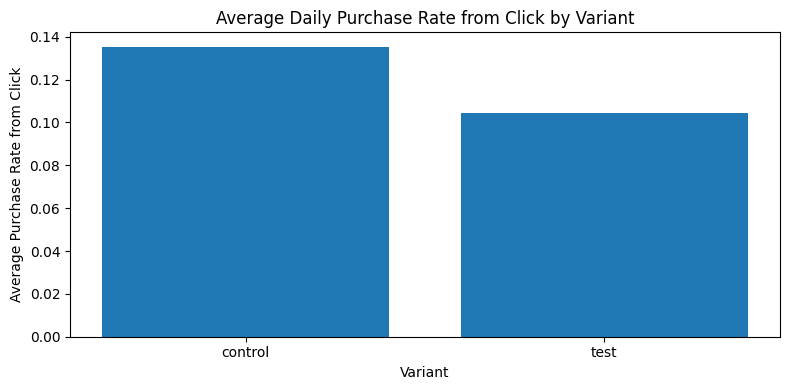

In [24]:
# Plot the primary metric by variant

primary_metric_plot_df = (
    ab_daily.groupby("variant", as_index=False)
    .agg(avg_purchase_rate_from_click=("purchase_rate_from_click", "mean"))
)

plt.figure(figsize=(8, 4))
plt.bar(primary_metric_plot_df["variant"], primary_metric_plot_df["avg_purchase_rate_from_click"])
plt.title("Average Daily Purchase Rate from Click by Variant")
plt.xlabel("Variant")
plt.ylabel("Average Purchase Rate from Click")
plt.tight_layout()
plt.show()

In [25]:
# Save A/B statistical testing results

ab_daily.to_csv(PREDICTIONS_DIR / "ab_daily_metrics.csv", index=False)
ab_test_results_df.to_csv(PREDICTIONS_DIR / "ab_test_results.csv", index=False)

print("A/B statistical testing outputs saved successfully.")

A/B statistical testing outputs saved successfully.


## Select Uplift Metric

This section selects the purchase-related uplift metric that will be translated into revenue scenarios.

In [6]:
# Select uplift metric for scenario analysis

selected_uplift_metric = "purchase_rate_from_click"

selected_uplift_row = ab_uplift_summary[
    ab_uplift_summary["metric"] == selected_uplift_metric
].copy()

selected_uplift_row

,metric,control_value,test_value,absolute_diff,relative_uplift_pct
1,purchase_rate_from_click,0.098255,0.086407,-0.011848,-12.058601


In [26]:
# Build scenario assumption table

selected_uplift_pct = selected_uplift_row["relative_uplift_pct"].iloc[0]

scenario_assumptions_df = pd.DataFrame({
    "scenario": ["control", "conservative", "base", "optimistic"],
    "uplift_pct": [
        0.0,
        selected_uplift_pct * 0.50,
        selected_uplift_pct,
        selected_uplift_pct * 1.25
    ]
})

scenario_assumptions_df["multiplier"] = 1 + (scenario_assumptions_df["uplift_pct"] / 100)

scenario_assumptions_df

,scenario,uplift_pct,multiplier
0,control,0.000000,1.000000
1,conservative,-6.029300,0.939707
2,base,-12.058601,0.879414
3,optimistic,-15.073251,0.849267


In [27]:
ab_daily.to_csv(PREDICTIONS_DIR / "ab_daily_metrics.csv", index=False)
ab_test_results_df.to_csv(PREDICTIONS_DIR / "ab_test_results.csv", index=False)

## Select Forecast Benchmark

This section identifies the strongest available forecasting benchmark that will anchor the scenario analysis.

In [8]:
# Review combined model results

combined_model_results_df.sort_values("rmse").head(10)

,model,mae,rmse,mape
0,xgboost,35665.184397,52884.114952,4.005502
1,random_forest,39444.340058,53734.890817,4.523485
2,prophet_multiplicative,51598.263671,62955.223357,5.942615
3,linear_regression,51635.890600,66741.014312,6.033416
4,prophet_more_flexible,53538.724862,68885.254196,6.193390
5,prophet,50123.703649,71571.140724,5.442261
6,prophet_default_like,50123.703649,71571.140724,5.442261
7,sarimax,77766.983441,105221.559263,8.314835
8,seasonal_naive_lag_7,93934.855404,122634.696828,10.465347
9,naive_last_value,129317.639233,164712.494255,14.716884


In [9]:
# Select current best benchmark

best_model_row = combined_model_results_df.sort_values("rmse").iloc[0]
best_model_row

model         xgboost
mae      35665.184397
rmse     52884.114952
mape         4.005502
Name: 0, dtype: object

## Build Forecast Base Path

This section loads the best available validation prediction path to serve as the baseline revenue projection.

In [10]:
# Load best available baseline forecast path

baseline_validation_df = pd.read_csv(
    PREDICTIONS_DIR / "baseline_time_series_validation_predictions.csv",
    parse_dates=["date"]
)

baseline_validation_df.head()

,date,total_sales,naive_last_value,seasonal_naive_lag_7,moving_avg_7,sarimax,prophet
0,2017-05-18,6.284880e+05,841407.607944,6.486504e+05,840983.815566,6.566946e+05,6.322272e+05
1,2017-05-19,7.737754e+05,841407.607944,7.648124e+05,840983.815566,7.690044e+05,7.433830e+05
2,2017-05-20,1.035667e+06,841407.607944,1.116977e+06,840983.815566,9.837399e+05,9.336161e+05
3,2017-05-21,1.201939e+06,841407.607944,8.841999e+05,840983.815566,1.045641e+06,1.033110e+06
4,2017-05-22,7.789352e+05,841407.607944,8.230356e+05,840983.815566,8.136293e+05,7.694364e+05


In [11]:
# Select multiplicative Prophet forecast as baseline scenario path

if "prophet_multiplicative" in baseline_validation_df.columns:
    scenario_base_df = baseline_validation_df[["date", "total_sales", "prophet_multiplicative"]].copy()
    scenario_base_df = scenario_base_df.rename(columns={"prophet_multiplicative": "baseline_forecast"})
else:
    scenario_base_df = baseline_validation_df[["date", "total_sales", "prophet"]].copy()
    scenario_base_df = scenario_base_df.rename(columns={"prophet": "baseline_forecast"})

scenario_base_df.head()

,date,total_sales,baseline_forecast
0,2017-05-18,6.284880e+05,6.322272e+05
1,2017-05-19,7.737754e+05,7.433830e+05
2,2017-05-20,1.035667e+06,9.336161e+05
3,2017-05-21,1.201939e+06,1.033110e+06
4,2017-05-22,7.789352e+05,7.694364e+05


## Create Revenue Scenarios

This section applies experiment uplift multipliers to the forecast baseline to simulate revenue under different rollout cases.

In [13]:
# Apply scenario multipliers to forecast baseline

scenario_forecast_df = scenario_base_df.copy()

for row in scenario_assumptions_df.itertuples(index=False):
    scenario_name = row.scenario
    multiplier = row.multiplier
    scenario_forecast_df[f"{scenario_name}_forecast"] = scenario_forecast_df["baseline_forecast"] * multiplier

scenario_forecast_df.head()

,date,total_sales,baseline_forecast,control_forecast,conservative_forecast,base_forecast,optimistic_forecast
0,2017-05-18,6.284880e+05,6.322272e+05,6.322272e+05,594108.293606,555989.418810,536929.981412
1,2017-05-19,7.737754e+05,7.433830e+05,7.433830e+05,698562.209171,653741.415259,631331.018303
2,2017-05-20,1.035667e+06,9.336161e+05,9.336161e+05,877325.557452,821035.040319,792889.781752
3,2017-05-21,1.201939e+06,1.033110e+06,1.033110e+06,970820.262555,908530.985606,877386.347132
4,2017-05-22,7.789352e+05,7.694364e+05,7.694364e+05,723044.730933,676653.101886,653457.287362


## Revenue Impact Summary

This section summarizes baseline and uplift-adjusted revenue totals for each scenario.

In [14]:
# Summarize projected revenue by scenario

scenario_summary_df = pd.DataFrame({
    "scenario": ["control", "conservative", "base", "optimistic"],
    "projected_revenue": [
        scenario_forecast_df["control_forecast"].sum(),
        scenario_forecast_df["conservative_forecast"].sum(),
        scenario_forecast_df["base_forecast"].sum(),
        scenario_forecast_df["optimistic_forecast"].sum()
    ]
})

control_total = scenario_summary_df.loc[
    scenario_summary_df["scenario"] == "control",
    "projected_revenue"
].iloc[0]

scenario_summary_df["incremental_revenue_vs_control"] = (
    scenario_summary_df["projected_revenue"] - control_total
)

scenario_summary_df["pct_lift_vs_control"] = (
    scenario_summary_df["incremental_revenue_vs_control"] / control_total
) * 100

scenario_summary_df

,scenario,projected_revenue,incremental_revenue_vs_control,pct_lift_vs_control
0,control,7.535353e+07,0.000000e+00,0.000000
1,conservative,7.081024e+07,-4.543291e+06,-6.029300
2,base,6.626695e+07,-9.086581e+06,-12.058601
3,optimistic,6.399530e+07,-1.135823e+07,-15.073251


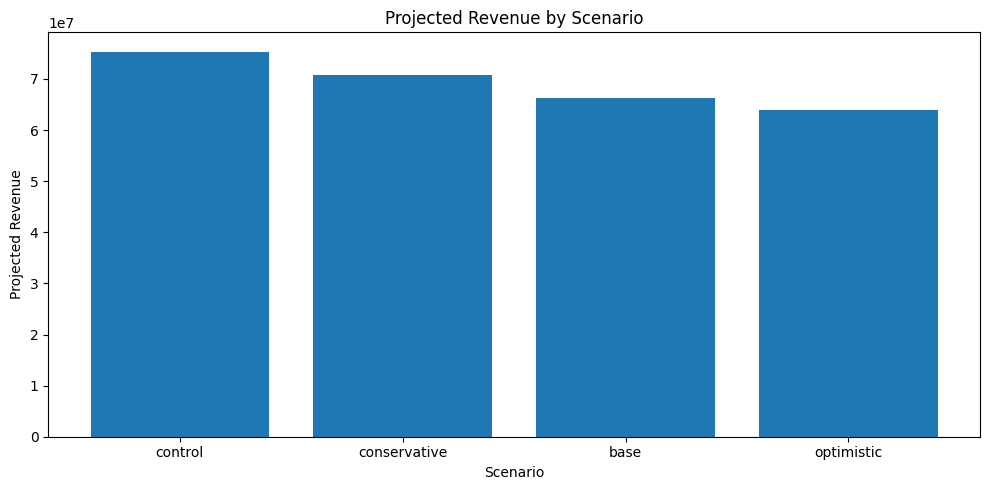

In [15]:
# Plot projected revenue by scenario

plt.figure(figsize=(10, 5))
plt.bar(scenario_summary_df["scenario"], scenario_summary_df["projected_revenue"])
plt.title("Projected Revenue by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Projected Revenue")
plt.tight_layout()
plt.show()

## Scenario Forecast Paths

This section compares daily revenue paths across the control and uplift scenarios.

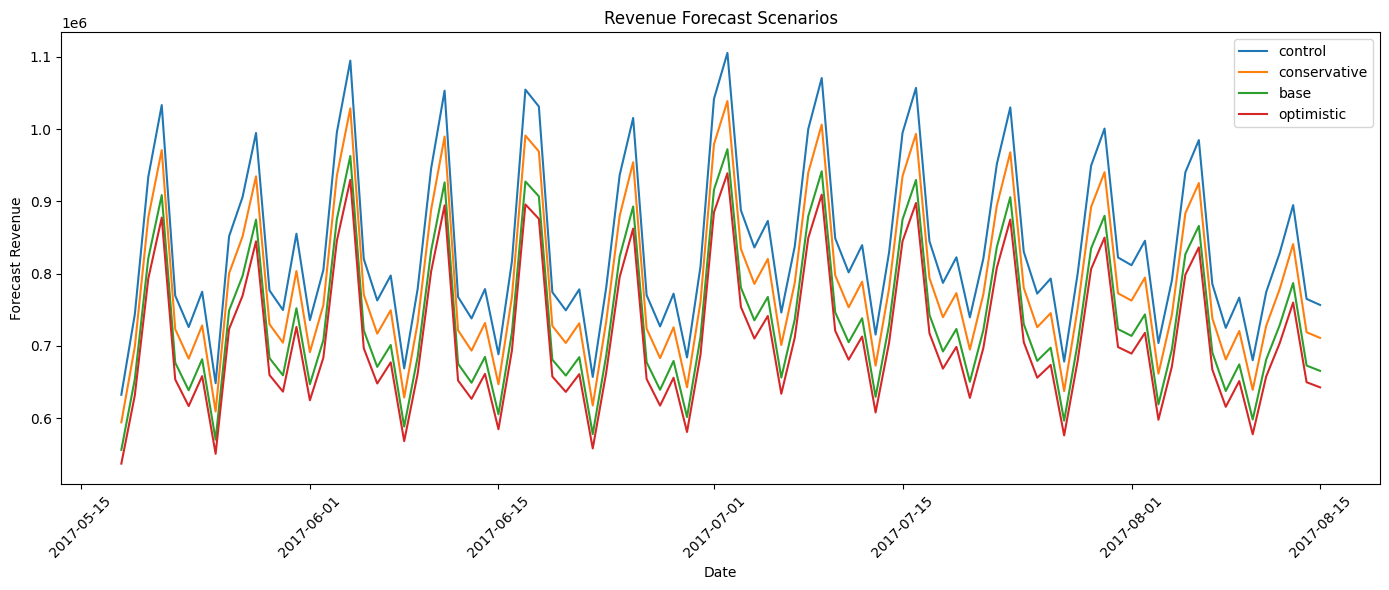

In [16]:
# Plot scenario forecast paths

plt.figure(figsize=(14, 6))
plt.plot(scenario_forecast_df["date"], scenario_forecast_df["control_forecast"], label="control")
plt.plot(scenario_forecast_df["date"], scenario_forecast_df["conservative_forecast"], label="conservative")
plt.plot(scenario_forecast_df["date"], scenario_forecast_df["base_forecast"], label="base")
plt.plot(scenario_forecast_df["date"], scenario_forecast_df["optimistic_forecast"], label="optimistic")
plt.title("Revenue Forecast Scenarios")
plt.xlabel("Date")
plt.ylabel("Forecast Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Business Recommendation Table

This section prepares a compact decision-support summary for rollout planning.

In [17]:
# Create business recommendation table

business_recommendation_df = scenario_summary_df.copy()

business_recommendation_df["recommendation_note"] = [
    "No rollout uplift applied",
    "Use if experiment lift is real but weaker than observed",
    "Use as main business planning case",
    "Use as upside case if rollout effect scales strongly"
]

business_recommendation_df

,scenario,projected_revenue,incremental_revenue_vs_control,pct_lift_vs_control,recommendation_note
0,control,7.535353e+07,0.000000e+00,0.000000,No rollout uplift applied
1,conservative,7.081024e+07,-4.543291e+06,-6.029300,Use if experiment lift is real but weaker than...
2,base,6.626695e+07,-9.086581e+06,-12.058601,Use as main business planning case
3,optimistic,6.399530e+07,-1.135823e+07,-15.073251,Use as upside case if rollout effect scales st...


## Save Scenario Outputs

This section saves scenario tables and forecast paths for the final dashboard and business recommendation notebook.

In [28]:
# Save scenario analysis outputs

scenario_assumptions_df.to_csv(PREDICTIONS_DIR / "scenario_assumptions.csv", index=False)
scenario_forecast_df.to_csv(PREDICTIONS_DIR / "scenario_forecast_paths.csv", index=False)
scenario_summary_df.to_csv(PREDICTIONS_DIR / "scenario_summary.csv", index=False)
business_recommendation_df.to_csv(PREDICTIONS_DIR / "business_recommendation_table.csv", index=False)

print("Scenario analysis outputs saved successfully.")

Scenario analysis outputs saved successfully.


In [29]:
# Confirm saved scenario files

for file in PREDICTIONS_DIR.iterdir():
    print(file.name)

ab_daily_metrics.csv
ab_test_results.csv
baseline_time_series_results.csv
baseline_time_series_validation_predictions.csv
business_recommendation_table.csv
combined_model_results.csv
ml_model_results.csv
ml_validation_predictions.csv
prophet_diagnostics.csv
prophet_tuning_results.csv
rf_feature_importance.csv
scenario_assumptions.csv
scenario_forecast_paths.csv
scenario_summary.csv
worst_prophet_errors.csv
xgb_feature_importance.csv


## Notebook Summary

This notebook:

1. Reviewed A/B experiment uplift
2. Selected a purchase-related uplift metric
3. Identified the strongest forecast benchmark
4. Applied uplift assumptions to forecasted revenue
5. Created control, conservative, base, and optimistic revenue scenarios
6. Produced business-facing revenue impact summaries

The next notebook will organize these outputs into a final dashboard-ready and stakeholder-ready recommendation.